In [1]:
#Importing Libraries
import pandas as pd 
from datasets import load_dataset
import matplotlib.pyplot as plt 


#Loading data 
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

In [3]:
type(df['job_type_skills'])

pandas.core.series.Series

In [12]:
import ast
df['job_type_skills'] = df['job_type_skills'].apply(lambda clean: ast.literal_eval(clean)
                                                    if isinstance(clean, str)
                                                    and clean.startswith('{')
                                                    else clean)
df_exploded = df.explode('job_type_skills')
df_exploded['job_type_skills']

0                  None
1         analyst_tools
1           programming
2         analyst_tools
2                 cloud
              ...      
785739        libraries
785739            other
785739      programming
785740            cloud
785740            other
Name: job_type_skills, Length: 1905929, dtype: object

<Axes: xlabel='job_type_skills'>

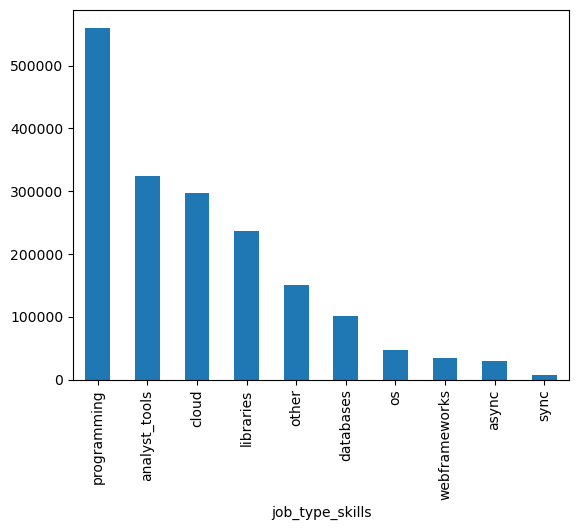

In [14]:
df_exploded['job_type_skills'].value_counts().head(10).plot(kind='bar')

In [17]:
skill_count = df_exploded.groupby(['job_title_short','job_type_skills']).size()
skill_count

job_title_short    job_type_skills
Business Analyst   analyst_tools      28746
                   async               2164
                   cloud               7293
                   databases           2746
                   libraries           2785
                                      ...  
Software Engineer  os                  7704
                   other              15537
                   programming        31437
                   sync                 896
                   webframeworks       7066
Length: 100, dtype: int64

In [28]:
# Converting to dataframe and fixing missing collumn name
df_skill_count = skill_count.reset_index(name='skills_count')
df_skill_count

,job_title_short,job_type_skills,skills_count
0,Business Analyst,analyst_tools,28746
1,Business Analyst,async,2164
2,Business Analyst,cloud,7293
3,Business Analyst,databases,2746
4,Business Analyst,libraries,2785
...,...,...,...
95,Software Engineer,os,7704
96,Software Engineer,other,15537
97,Software Engineer,programming,31437
98,Software Engineer,sync,896


In [33]:
df_skill_count = df_skill_count.sort_values(by='skills_count', ascending=False).head(20)
df_skill_count


,job_title_short,job_type_skills,skills_count
37,Data Engineer,programming,151423
47,Data Scientist,programming,132788
20,Data Analyst,analyst_tools,123001
32,Data Engineer,cloud,121738
27,Data Analyst,programming,117297
34,Data Engineer,libraries,88407
40,Data Scientist,analyst_tools,61179
44,Data Scientist,libraries,60714
36,Data Engineer,other,55544
30,Data Engineer,analyst_tools,54976


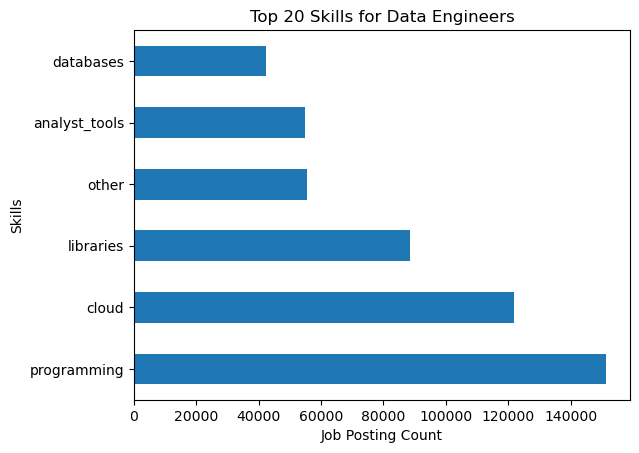

In [41]:
job_title = 'Data Engineer'
top_skills = 20
df_top_20 = df_skill_count[df_skill_count['job_title_short']==job_title].head(top_skills)
df_top_20.plot(kind='barh',x='job_type_skills',y='skills_count')
plt.gca().invert_yaxis
plt.title(f'Top {top_skills} Skills for {job_title}s')
plt.xlabel('Job Posting Count')
plt.ylabel('Skills')
plt.legend().set_visible(False)


